In [3]:
from google.colab import files
upload = files.upload()

Saving SuperStoreOrders.csv to SuperStoreOrders.csv


In [4]:
import pandas as pd
import numpy as np

df= pd.read_csv('SuperStoreOrders.csv')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 51290
Columns: 21


In [5]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [7]:
df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_name',
 'segment',
 'state',
 'country',
 'market',
 'region',
 'product_id',
 'category',
 'sub_category',
 'product_name',
 'sales',
 'quantity',
 'discount',
 'profit',
 'shipping_cost',
 'order_priority',
 'year']

In [8]:
df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_name,0
segment,0
state,0
country,0
market,0
region,0


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [10]:
# Create a unique Customer ID from customer names
df['customer_id'] = pd.factorize(df['customer_name'])[0] + 1

df[['customer_id', 'customer_name']].drop_duplicates().head(10)

,customer_id,customer_name
0,1,Toby Braunhardt
1,2,Joseph Holt
2,3,Annie Thurman
3,4,Eugene Moren
6,5,Magdelene Morse
7,6,Kean Nguyen
8,7,Ken Lonsdale
9,8,Lindsay Williams
10,9,Larry Blacks
12,10,Dorothy Dickinson


In [11]:
sales_df = df[
    [
        'order_id',
        'order_date',
        'ship_date',
        'ship_mode',
        'customer_id',
        'customer_name',
        'product_id',
        'sales',
        'quantity',
        'discount',
        'profit',
        'shipping_cost',
        'order_priority',
        'year'
    ]
].copy()

print("Sales Dataset:", sales_df.shape)
sales_df.head()

Sales Dataset: (51290, 14)


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,product_id,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,2,Joseph Holt,OFF-SU-10000618,120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,3,Annie Thurman,OFF-TEN-10001585,66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,4,Eugene Moren,OFF-PA-10001492,45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,2,Joseph Holt,FUR-FU-10003447,114,5,0.1,37.770,4.70,Medium,2011


In [12]:
products_df = df[
    [
        'product_id',
        'product_name',
        'category',
        'sub_category'
    ]
].drop_duplicates().copy()

print("Products Dataset:", products_df.shape)
products_df.head()

Products Dataset: (10768, 4)


,product_id,product_name,category,sub_category
0,OFF-TEN-10000025,"Tenex Lockers, Blue",Office Supplies,Storage
1,OFF-SU-10000618,"Acme Trimmer, High Speed",Office Supplies,Supplies
2,OFF-TEN-10001585,"Tenex Box, Single Width",Office Supplies,Storage
3,OFF-PA-10001492,"Enermax Note Cards, Premium",Office Supplies,Paper
4,FUR-FU-10003447,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings


In [13]:
customers_df = df[
    [
        'customer_id',
        'customer_name',
        'segment',
        'state',
        'country',
        'market',
        'region'
    ]
].drop_duplicates().copy()

print("Customers Dataset:", customers_df.shape)
customers_df.head()

Customers Dataset: (23364, 7)


,customer_id,customer_name,segment,state,country,market,region
0,1,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa
1,2,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania
2,3,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA
3,4,Eugene Moren,Home Office,Stockholm,Sweden,EU,North
6,5,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada


In [14]:
print("Sales:", sales_df.shape)
print("Products:", products_df.shape)
print("Customers:", customers_df.shape)

Sales: (51290, 14)
Products: (10768, 4)
Customers: (23364, 7)


In [15]:
merged_df = sales_df.merge(
    products_df,
    on='product_id',
    how='left'
)

print("Merged Sales + Products:", merged_df.shape)
merged_df.head()

Merged Sales + Products: (55996, 17)


,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,product_id,sales,quantity,discount,profit,shipping_cost,order_priority,year,product_name,category,sub_category
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,106.140,35.46,Medium,2011,"Tenex Lockers, Blue",Office Supplies,Storage
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,2,Joseph Holt,OFF-SU-10000618,120,3,0.1,36.036,9.72,Medium,2011,"Acme Trimmer, High Speed",Office Supplies,Supplies
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,3,Annie Thurman,OFF-TEN-10001585,66,4,0.0,29.640,8.17,High,2011,"Tenex Box, Single Width",Office Supplies,Storage
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,4,Eugene Moren,OFF-PA-10001492,45,3,0.5,-26.055,4.82,High,2011,"Enermax Note Cards, Premium",Office Supplies,Paper
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,2,Joseph Holt,FUR-FU-10003447,114,5,0.1,37.770,4.70,Medium,2011,"Eldon Light Bulb, Duo Pack",Furniture,Furnishings


In [16]:
merged_df = merged_df.merge(
    customers_df,
    on='customer_id',
    how='left',
    suffixes=('', '_customer')
)

print("Final Merged Dataset:", merged_df.shape)
merged_df.head()

Final Merged Dataset: (1688106, 23)


,order_id,order_date,ship_date,ship_mode,customer_id,...,segment,state,country,market,region
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,...,Consumer,Constantine,Algeria,Africa,Africa
1,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,...,Consumer,Kaluga,Russia,EMEA,EMEA
2,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,...,Consumer,Ontario,Canada,Canada,Canada
3,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,...,Consumer,Bogota,Colombia,LATAM,South
4,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,...,Consumer,New York,United States,US,East


In [17]:
merged_df.columns.tolist()

['order_id',
 'order_date',
 'ship_date',
 'ship_mode',
 'customer_id',
 'customer_name',
 'product_id',
 'sales',
 'quantity',
 'discount',
 'profit',
 'shipping_cost',
 'order_priority',
 'year',
 'product_name',
 'category',
 'sub_category',
 'customer_name_customer',
 'segment',
 'state',
 'country',
 'market',
 'region']

In [18]:
merged_df.isnull().sum()

,0
order_id,0
order_date,0
ship_date,0
ship_mode,0
customer_id,0
customer_name,0
product_id,0
sales,0
quantity,0
discount,0


In [24]:
merged_df.shape

(1688106, 24)

In [25]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1688106 entries, 0 to 1688105
Data columns (total 24 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1688106 non-null  object 
 1   order_date              1688106 non-null  object 
 2   ship_date               1688106 non-null  object 
 3   ship_mode               1688106 non-null  object 
 4   customer_id             1688106 non-null  int64  
 5   customer_name           1688106 non-null  object 
 6   product_id              1688106 non-null  object 
 7   sales                   1688106 non-null  object 
 8   quantity                1688106 non-null  int64  
 9   discount                1688106 non-null  float64
 10  profit                  1688106 non-null  float64
 11  shipping_cost           1688106 non-null  float64
 12  order_priority          1688106 non-null  object 
 13  year                    1688106 non-null  int64  
 14  pr

In [26]:
merged_df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,product_id,sales,quantity,discount,...,product_name,category,sub_category,customer_name_customer,segment,state,country,market,region,total_revenue
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,...,"Tenex Lockers, Blue",Office Supplies,Storage,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,408
1,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,...,"Tenex Lockers, Blue",Office Supplies,Storage,Toby Braunhardt,Consumer,Kaluga,Russia,EMEA,EMEA,408
2,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,...,"Tenex Lockers, Blue",Office Supplies,Storage,Toby Braunhardt,Consumer,Ontario,Canada,Canada,Canada,408
3,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,...,"Tenex Lockers, Blue",Office Supplies,Storage,Toby Braunhardt,Consumer,Bogota,Colombia,LATAM,South,408
4,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408,2,0.0,...,"Tenex Lockers, Blue",Office Supplies,Storage,Toby Braunhardt,Consumer,New York,United States,US,East,408


In [27]:
merged_df['total_revenue'] = merged_df['sales']

In [29]:
# Convert sales and profit columns to numeric
merged_df['sales'] = pd.to_numeric(merged_df['sales'], errors='coerce')
merged_df['profit'] = pd.to_numeric(merged_df['profit'], errors='coerce')

# Check the data types
print(merged_df[['sales', 'profit']].dtypes)

sales     float64
profit    float64
dtype: object


In [30]:
merged_df['total_revenue'] = merged_df['sales']

In [31]:
merged_df['profit_margin'] = (
    merged_df['profit'] / merged_df['sales']
) * 100

In [32]:
merged_df[['sales', 'profit', 'total_revenue', 'profit_margin']].head(10)

,sales,profit,total_revenue,profit_margin
0,408.0,106.14,408.0,26.014706
1,408.0,106.14,408.0,26.014706
2,408.0,106.14,408.0,26.014706
3,408.0,106.14,408.0,26.014706
4,408.0,106.14,408.0,26.014706
5,408.0,106.14,408.0,26.014706
6,408.0,106.14,408.0,26.014706
7,408.0,106.14,408.0,26.014706
8,408.0,106.14,408.0,26.014706
9,408.0,106.14,408.0,26.014706


In [33]:
customer_summary = merged_df.groupby('customer_id').agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('order_id', 'nunique'),
    total_quantity=('quantity', 'sum')
).reset_index()

customer_summary['average_order_value'] = (
    customer_summary['total_revenue'] /
    customer_summary['total_orders']
)

customer_summary['customer_lifetime_value'] = (
    customer_summary['average_order_value'] *
    customer_summary['total_orders']
)

customer_summary.head(10)

,customer_id,total_revenue,total_orders,total_quantity,average_order_value,customer_lifetime_value
0,1,383501.0,35,7502,10957.171429,383501.0
1,2,574002.0,45,13923,12755.600000,574002.0
2,3,222662.0,34,5829,6548.882353,222662.0
3,4,654840.0,36,13464,18190.000000,654840.0
4,5,267876.0,31,6412,8641.161290,267876.0
5,6,445625.0,34,8370,13106.617647,445625.0
6,7,393385.0,33,8352,11920.757576,393385.0
7,8,235569.0,34,5859,6928.500000,235569.0
8,9,425355.0,36,8645,11815.416667,425355.0
9,10,344224.0,32,7843,10757.000000,344224.0


In [35]:
merged_df = merged_df.merge(
    customer_summary[
        ['customer_id', 'customer_lifetime_value']
    ],
    on='customer_id',
    how='left'
)

merged_df.head()

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,product_id,sales,quantity,discount,...,sub_category,customer_name_customer,segment,state,country,market,region,total_revenue,profit_margin,customer_lifetime_value
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408.0,2,0.0,...,Storage,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,408.0,26.014706,383501.0
1,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408.0,2,0.0,...,Storage,Toby Braunhardt,Consumer,Kaluga,Russia,EMEA,EMEA,408.0,26.014706,383501.0
2,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408.0,2,0.0,...,Storage,Toby Braunhardt,Consumer,Ontario,Canada,Canada,Canada,408.0,26.014706,383501.0
3,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408.0,2,0.0,...,Storage,Toby Braunhardt,Consumer,Bogota,Colombia,LATAM,South,408.0,26.014706,383501.0
4,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,1,Toby Braunhardt,OFF-TEN-10000025,408.0,2,0.0,...,Storage,Toby Braunhardt,Consumer,New York,United States,US,East,408.0,26.014706,383501.0


In [36]:
merged_df[
    ['customer_id', 'customer_name',
     'total_revenue', 'profit_margin',
     'customer_lifetime_value']
].head(10)

,customer_id,customer_name,total_revenue,profit_margin,customer_lifetime_value
0,1,Toby Braunhardt,408.0,26.014706,383501.0
1,1,Toby Braunhardt,408.0,26.014706,383501.0
2,1,Toby Braunhardt,408.0,26.014706,383501.0
3,1,Toby Braunhardt,408.0,26.014706,383501.0
4,1,Toby Braunhardt,408.0,26.014706,383501.0
5,1,Toby Braunhardt,408.0,26.014706,383501.0
6,1,Toby Braunhardt,408.0,26.014706,383501.0
7,1,Toby Braunhardt,408.0,26.014706,383501.0
8,1,Toby Braunhardt,408.0,26.014706,383501.0
9,1,Toby Braunhardt,408.0,26.014706,383501.0


In [37]:
merged_df = merged_df.merge(
    customer_summary[['customer_id', 'customer_lifetime_value']],
    on='customer_id',
    how='left'
)

print("CLV added successfully!")

CLV added successfully!


In [40]:
customer_summary = merged_df.groupby('customer_id').agg(
    total_revenue=('total_revenue', 'sum'),
    total_orders=('order_id', 'nunique'),
    total_quantity=('quantity', 'sum')
).reset_index()

customer_summary['average_order_value'] = (
    customer_summary['total_revenue'] /
    customer_summary['total_orders']
)

customer_summary['customer_lifetime_value'] = (
    customer_summary['average_order_value'] *
    customer_summary['total_orders']
)

customer_summary.head()

,customer_id,total_revenue,total_orders,total_quantity,average_order_value,customer_lifetime_value
0,1,383501.0,35,7502,10957.171429,383501.0
1,2,574002.0,45,13923,12755.600000,574002.0
2,3,222662.0,34,5829,6548.882353,222662.0
3,4,654840.0,36,13464,18190.000000,654840.0
4,5,267876.0,31,6412,8641.161290,267876.0


In [41]:
merged_df = merged_df.merge(
    customer_summary[['customer_id', 'customer_lifetime_value']],
    on='customer_id',
    how='left'
)

print("CLV successfully added!")

CLV successfully added!


In [42]:
merged_df[
    [
        'customer_id',
        'customer_name',
        'total_revenue',
        'profit_margin',
        'customer_lifetime_value'
    ]
].head(10)

,customer_id,customer_name,total_revenue,profit_margin,customer_lifetime_value
0,1,Toby Braunhardt,408.0,26.014706,383501.0
1,1,Toby Braunhardt,408.0,26.014706,383501.0
2,1,Toby Braunhardt,408.0,26.014706,383501.0
3,1,Toby Braunhardt,408.0,26.014706,383501.0
4,1,Toby Braunhardt,408.0,26.014706,383501.0
5,1,Toby Braunhardt,408.0,26.014706,383501.0
6,1,Toby Braunhardt,408.0,26.014706,383501.0
7,1,Toby Braunhardt,408.0,26.014706,383501.0
8,1,Toby Braunhardt,408.0,26.014706,383501.0
9,1,Toby Braunhardt,408.0,26.014706,383501.0


In [43]:
print("Total rows:", len(merged_df))
print("Total columns:", len(merged_df.columns))

print("\nNew Features:")
print("✓ total_revenue")
print("✓ profit_margin")
print("✓ customer_lifetime_value")

Total rows: 1688106
Total columns: 28

New Features:
✓ total_revenue
✓ profit_margin
✓ customer_lifetime_value


In [44]:
top_customers = (
    merged_df.groupby(['customer_id', 'customer_name'])['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_customers

,,total_revenue
customer_id,customer_name,
72,Eric Murdock,841620.0
784,Theone Pippenger,746774.0
487,John Grady,729820.0
268,Bart Watters,703519.0
36,Maria Etezadi,702612.0
273,Laura Armstrong,700341.0
519,Dan Reichenbach,682395.0
169,Nathan Mautz,681940.0
622,Steven Ward,674748.0


In [45]:
top_products = (
    merged_df.groupby(['product_id', 'product_name'])['total_revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

product_id       product_name                                
FUR-CH-10003354  Harbour Creations Swivel Stool, Red             257956.0
                 Novimex Bag Chairs, Black                       257956.0
OFF-ST-10004377  Rogers File Cart, Single Width                  238277.0
OFF-ST-10002555  Eldon Lockers, Industrial                       238214.0
OFF-ST-10000624  Eldon File Cart, Single Width                   215943.0
OFF-ST-10003785  Eldon Lockers, Blue                             214924.0
OFF-ST-10003306  Eldon File Cart, Single Width                   198437.0
                 Letter Size Cart                                198437.0
FUR-CH-10004095  SAFCO Executive Leather Armchair, Adjustable    198272.0
                 Novimex Steel Folding Chair, Black              198272.0
Name: total_revenue, dtype: float64

In [47]:
category_revenue = (
    merged_df.groupby('category')['total_revenue']
    .sum()
    .sort_values(ascending=False)
)

category_revenue

,total_revenue
category,
Office Supplies,92401328.0
Technology,86593082.0
Furniture,79235770.0


In [48]:
category_profit = (
    merged_df.groupby('category')['profit']
    .sum()
    .sort_values(ascending=False)
)

category_profit

,profit
category,
Technology,2.200793e+07
Office Supplies,1.737736e+07
Furniture,9.258795e+06


In [50]:
category_margin = (
    merged_df.groupby('category')['profit_margin']
    .mean()
    .sort_values(ascending=False)
)

category_margin

,profit_margin
category,
Technology,3.664118
Furniture,0.400641
Office Supplies,-inf


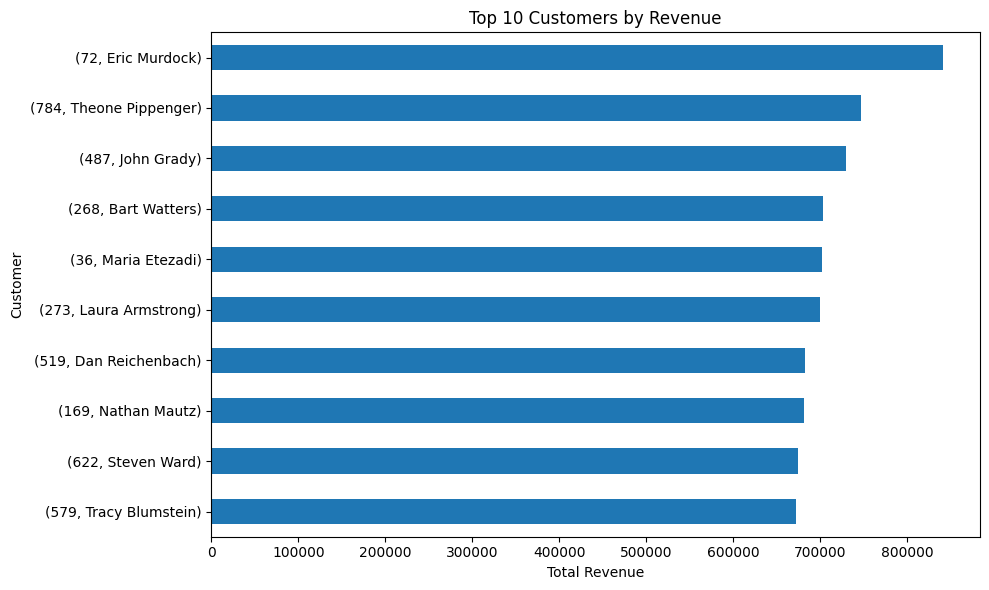

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

top_customers.sort_values().plot(kind='barh')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer')
plt.tight_layout()
plt.show()

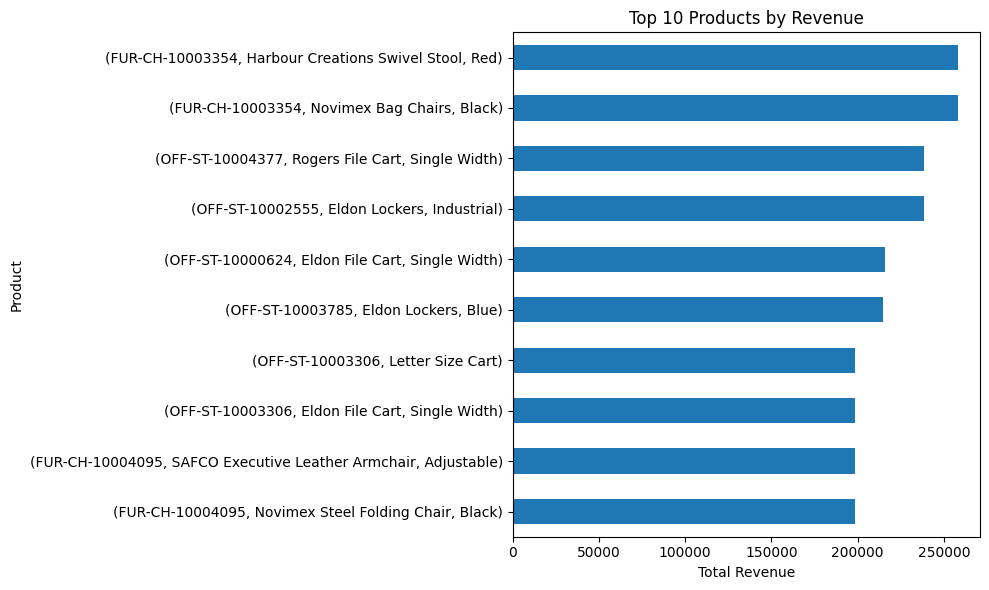

In [52]:
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind='barh')

plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

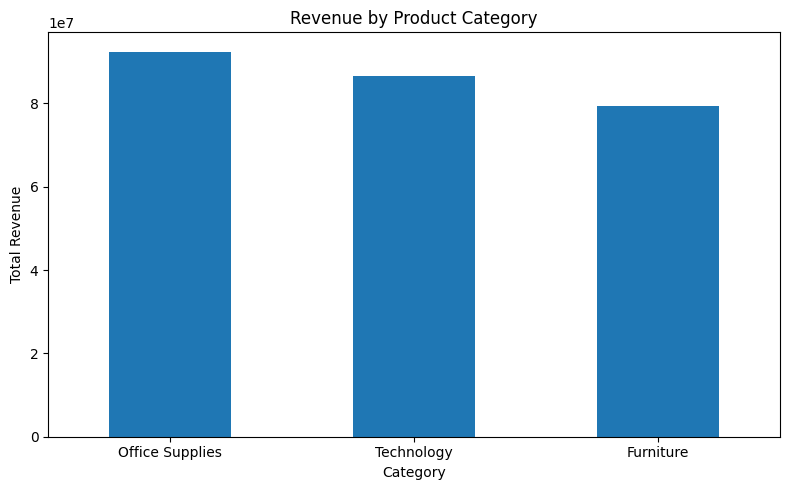

In [53]:
plt.figure(figsize=(8, 5))

category_revenue.plot(kind='bar')

plt.title('Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Revenue')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

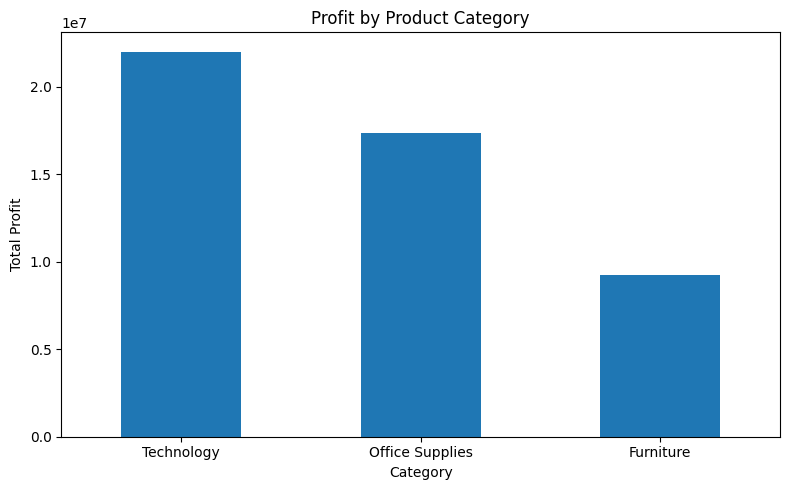

In [54]:
plt.figure(figsize=(8, 5))

category_profit.plot(kind='bar')

plt.title('Profit by Product Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

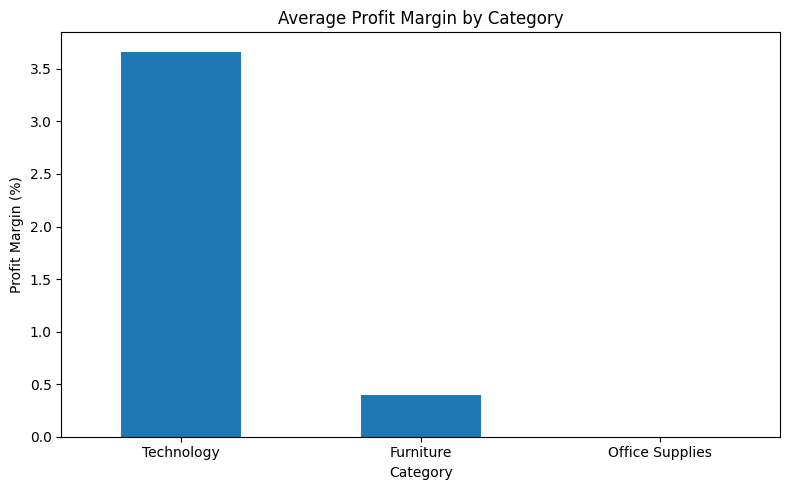

In [55]:
plt.figure(figsize=(8, 5))

category_margin.plot(kind='bar')

plt.title('Average Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Profit Margin (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [56]:
print("Final Dataset Shape:", merged_df.shape)
print("\nColumns:")
print(merged_df.columns.tolist())

Final Dataset Shape: (1688106, 28)

Columns:
['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'product_id', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year', 'product_name', 'category', 'sub_category', 'customer_name_customer', 'segment', 'state', 'country', 'market', 'region', 'total_revenue', 'profit_margin', 'customer_lifetime_value_x', 'customer_lifetime_value_y', 'customer_lifetime_value']


In [57]:
print("\nMissing Values:")
print(merged_df.isnull().sum().sum())


Missing Values:
261843


In [58]:
print("\nDuplicate Rows:", merged_df.duplicated().sum())


Duplicate Rows: 0


In [59]:
merged_df[
    [
        'order_id',
        'customer_name',
        'product_name',
        'sales',
        'profit',
        'total_revenue',
        'profit_margin',
        'customer_lifetime_value'
    ]
].head(10)

,order_id,customer_name,product_name,sales,profit,total_revenue,profit_margin,customer_lifetime_value
0,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
1,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
2,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
3,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
4,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
5,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
6,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
7,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
8,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0
9,AG-2011-2040,Toby Braunhardt,"Tenex Lockers, Blue",408.0,106.14,408.0,26.014706,383501.0


In [60]:
final_file = 'SuperStore_Final_Analysis.csv'

merged_df.to_csv(final_file, index=False)

print(f"File saved successfully as {final_file}")

File saved successfully as SuperStore_Final_Analysis.csv


In [61]:
from google.colab import files

files.download(final_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>